In [1]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import plotly
import matplotlib
import pandas as pd
import plotly.graph_objects as go

In [2]:
h.load_file("main.hoc")

	1 
	1 
	1 
	1 
	0 
	1 
23 
	1 
	1 
After any change to cell geometry or nseg, be sure to invoke setpointers()
	1 
	1 
	1 
	1 
Use setstim(DEL, DUR, F0, F1, AMP, PHASE) to change latency (ms), duration (ms),
start and end frequency (Hz), amplitude (V/m) and phase (degrees) of applied
electrical field.
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 


1.0

In [3]:
def set_stimulus(delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    h.setstim(delay, duration, frequency1, frequency2, amplitude, phase)

In [25]:
frequency1 = 1000
frequency2 = 1005
amplitude = 200

set_stimulus(
    delay = 0,
    duration = 1000,
    frequency1 = frequency1,
    frequency2 = frequency2,
    amplitude = amplitude,
    phase = 0
)

h.tstop = 1000

soma = h.Vector().record(h.soma[0](0.5)._ref_v)
t = h.Vector().record(h._ref_t)

h.run()

result1 = pd.DataFrame({
    "Time": t,
    "Soma": soma,
    "Frequency1": frequency1,
    "Frequency2": frequency2,
    "Amplitude": amplitude
})

In [26]:
frequency1 = 1000
frequency2 = 1005
amplitude = 100

set_stimulus(
    delay = 0,
    duration = 1000,
    frequency1 = frequency1,
    frequency2 = frequency2,
    amplitude = amplitude,
    phase = 0
)

h.tstop = 1000

soma = h.Vector().record(h.soma[0](0.5)._ref_v)
t = h.Vector().record(h._ref_t)

h.run()

result2 = pd.DataFrame({
    "Time": t,
    "Soma": soma,
    "Frequency1": frequency1,
    "Frequency2": frequency2,
    "Amplitude": amplitude
})

In [27]:
frequency1 = 5
frequency2 = 5
amplitude = 25

set_stimulus(
    delay = 0,
    duration = 1000,
    frequency1 = frequency1,
    frequency2 = frequency2,
    amplitude = amplitude,
    phase = 0
)

h.tstop = 1000

soma = h.Vector().record(h.soma[0](0.5)._ref_v)
t = h.Vector().record(h._ref_t)

h.run()

result3 = pd.DataFrame({
    "Time": t,
    "Soma": soma,
    "Frequency1": frequency1,
    "Frequency2": frequency2,
    "Amplitude": amplitude
})

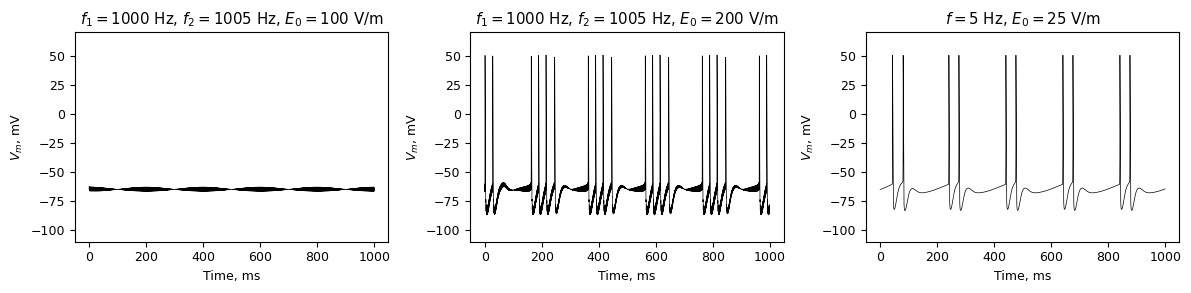

In [40]:
matplotlib.rcParams.update({"font.size": 9})

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))

axs[0].plot(result2.Time, result2.Soma, label = "Soma", lw = 0.5, color = "black")
axs[0].set_ylim(-110, 70)
axs[0].set_ylabel(r"$V_m$, mV")
axs[0].set_xlabel("Time, ms")
axs[0].set_title(r"$f_1 = 1000 \text{ Hz, } f_2 = 1005 \text{ Hz, } E_0 = 100 \text{ V/m}$")

axs[1].plot(result1.Time, result1.Soma, label = "Soma", lw = 0.5, color = "black")
axs[1].set_ylim(-110, 70)
axs[1].set_ylabel(r"$V_m$, mV")
axs[1].set_xlabel("Time, ms")
axs[1].set_title(r"$f_1 = 1000 \text{ Hz, } f_2 = 1005 \text{ Hz, } E_0 = 200 \text{ V/m}$")

axs[2].plot(result3.Time, result3.Soma, label = "Soma", lw = 0.5, color = "black")
axs[2].set_ylim(-110, 70)
axs[2].set_ylabel(r"$V_m$, mV")
axs[2].set_xlabel("Time, ms")
axs[2].set_title(r"$f = 5 \text{ Hz, } E_0 = 25 \text{ V/m}$")

fig.tight_layout()
plt.show()